<a href="https://colab.research.google.com/github/TomerRippin/Machine-Learning/blob/master/Maman12_DeepLearning_TomerRippin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maman 12 Deep Learning - Tomer Rippin
I.D - 322230608

In [ ]:
import torch

Assigment 1: my_sampler

part A: sampler function

The sampling algorithm:
1. if $U < p_0$ return $I = 0$
2. if $U >= \sum_{i=0}^{n-1}{p_i}$ return $I = n$
3. else find $k \in \{1 ... n-1\} $ s.t  $U < \sum_{i=0}^{k} p_i $ and $U >= \sum_{i=0}^{k-1}p_i$ and return $I=k$.

In [ ]:
def my_sampler(size, dist, requires_grad=False):
  """
  Function that samples the required distribution and returns a tensor of the required size.
  :param requires_grad: Wether or not the output tensor will be followed by an automatic grad system.

  :return: A tensor of the required size and distribution.
  """
  tdist = torch.tensor(dist)

  # Check the input
  assert (tdist.sum() == 1), "The distrebution sum should be 1."

  # Transfer the distrebution to cummuletive distrebution for easier calculations.
  tdist = torch.cumsum(tdist, dim=0)

  # Sample a random tensor with numbers between [0,1)
  sampled_tensor = torch.rand(size)

  # Follow the Sampling algorithm
  for i in range(len(dist)):
    if i == 0:
      sampled_tensor[sampled_tensor < tdist[i]] = i
    elif i == len(dist) - 1:
      sampled_tensor[(sampled_tensor >= tdist[i - 1]) & (sampled_tensor < 1)] = i
    else:
      sampled_tensor[(sampled_tensor >= tdist[i - 1]) & (sampled_tensor < tdist[i])] = i

  # Add the requires_grad to the final tensor
  sampled_tensor.requires_grad = requires_grad

  return sampled_tensor

In [ ]:
A=my_sampler((2,8),[0.1,0.2,0.7],requires_grad=True)
A

tensor([[2., 0., 1., 2., 1., 2., 1., 2.],
        [2., 2., 0., 2., 1., 2., 2., 2.]], requires_grad=True)

part B: Plot the result

(array([1006.,    0.,    0.,    0.,    0., 6997.,    0.,    0.,    0.,
        1997.]),
 array([0.        , 0.2       , 0.40000001, 0.60000002, 0.80000001,
        1.        , 1.20000005, 1.39999998, 1.60000002, 1.80000007,
        2.        ]),
 <BarContainer object of 10 artists>)

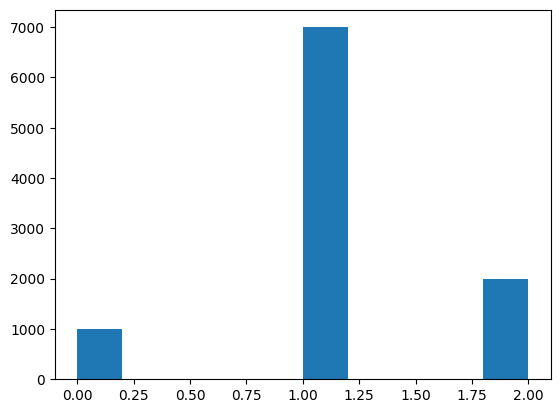

In [ ]:
import matplotlib

A = my_sampler(10000, [0.1, 0.7, 0.2])
matplotlib.pyplot.hist(A)

We can clearly see that our sampler worked as the distrebution in the histogram is the wanted distrebution.

Assigment  2: My Scalar

MyScalar function: initialization just like the class in the assigment

In [ ]:
class MyScalar:

  def __init__(self, value, local_grad=0, parent=None):
      self.value = value
      self.local_grad = local_grad  # d(self)/d(parent)
      self.parent = parent

def __repr__(self):
  return f"MyScalar(value={self.value}, local_grad={self.local}"

My gradients calculation library.

Each function recieves a MyScalar Object and returns a new object with a new scalar value, calculated immidiete gradient and a parant that is the input MyScalar object.

Implemented functions:

$\nabla_a(a+n) = a$

$\nabla_a(a*n) = n$

$\nabla_a(a^n) = n*a^{n-1}$

$\nabla_a cos(a) = sin(a)$

$\nabla_a sin(a) = cos(a)$

$\nabla_a ln(a) = 1/a$

$\nabla_a e^a = e^a$

In [ ]:
import math

def add(a: MyScalar, n):
  val = a.value + n
  return MyScalar(val, local_grad=1, parent=a)

def mult(a: MyScalar, n):
  val = a.value * n
  return MyScalar(val, local_grad=n, parent=a)

def power(a: MyScalar, n):
  val = math.pow(a.value, n)
  return MyScalar(val, local_grad=n * math.pow(a.value, n-1), parent=a)

def exp(a: MyScalar):
  val = math.exp(a.value)
  return MyScalar(val, local_grad=val, parent=a)

def cos(a: MyScalar):
  val = math.cos(a.value)
  return MyScalar(val, local_grad=-math.sin(a.value), parent=a)

def sin(a: MyScalar):
  val = math.sin(a.value)
  return MyScalar(val, local_grad=math.cos(a.value), parent=a)

def ln(a: MyScalar):
  val = math.log(a.value)
  return MyScalar(val, local_grad=1 / a.value, parent=a)

get_gradients function:

I didnt implemented it recursivly because in this way my code came out clearer.

In [ ]:
def get_gradient(target: MyScalar):
  gradients = {}

  current_grad = 1.0
  current = target

  # Chain rule
  while current is not None:
    gradients[current] = current_grad

    # If parent exiests, multiply by local_grad to get the gradient in relation to it
    if current.parent is not None:
      current_grad *= current.local_grad

    current = current.parent

  return gradients

Test on the assigment example

In [ ]:
a=MyScalar(2)
b=power(a,2) #a^2
c=exp(b)
d=get_gradient(c)

print(f"Value of c: {c.value}")
print(f"dc/dc: {d[c]}")
print(f"dc/db: {d[b]} (Expected: exp(4) ≈ 54.59)")
print(f"dc/da: {d[a]} (Expected: 2*a*exp(a^2) = 4*exp(4) ≈ 218.39)")

Value of c: 54.598150033144236
dc/dc: 1.0
dc/db: 54.598150033144236 (Expected: exp(4) ≈ 54.59)
dc/da: 218.39260013257694 (Expected: 2*a*exp(a^2) = 4*exp(4) ≈ 218.39)


Compare against the pytorch output

In [ ]:
def test_against_pytorch():
    val = 2.0
    print(f"Testing with input value: {val}\n" + "-"*30)

    # Test 1: ( exp(x^2) )
    # MyScalar
    a_c = MyScalar(val)
    b_c = power(a_c, 2)
    c_c = exp(b_c)
    grads_c = get_gradient(c_c)

    # PyTorch
    a_p = torch.tensor(val, requires_grad=True)
    c_p = torch.exp(a_p**2)
    c_p.backward()

    print(f"Test exp(x^2):")
    print(f"  MyScalar:  {grads_c[a_c]:.6f}")
    print(f"  PyTorch: {a_p.grad.item():.6f}")

    # Test 2: Linear and Trig ( 3*sin(x) + 5 )
    # MyScalar
    x_c = MyScalar(val)
    s_c = sin(x_c)
    l_c = mult(s_c, 3)
    a_c = add(l_c, 5)
    grads_l = get_gradient(a_c)

    # PyTorch
    x_p = torch.tensor(val, requires_grad=True)
    l_p = 3 * torch.sin(x_p) + 5
    l_p.backward()

    print(f"\nTest 3*sin(x) + 5:")
    print(f"  MyScalar:  {grads_l[x_c]:.6f}")
    print(f"  PyTorch: {x_p.grad.item():.6f}")

if __name__ == "__main__":
    test_against_pytorch()

Testing with input value: 2.0
------------------------------
Test exp(x^2):
  MyScalar:  218.392600
  PyTorch: 218.392593

Test 3*sin(x) + 5:
  MyScalar:  -1.248441
  PyTorch: -1.248441
